<a href="https://colab.research.google.com/github/mehaksingh0210/Sales-performance-analysis/blob/main/Sales_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# **Load Dataset**

In [7]:
df = pd.read_csv('SuperstoreSales_dataset.csv', encoding='latin1')
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


# **Data Cleaning**

# Check Missing Values

In [8]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


# Remove Duplicates

In [9]:
df.drop_duplicates(inplace=True)

# Convert Date Columns

In [12]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], format='%d-%m-%Y')

# Create Time Features

In [14]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.month_name()

# **Check Available Columns**

In [17]:
display(df.columns)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Year', 'Month', 'Month_Name'],
      dtype='object')

# **KPI Calculations**

# Total Revenue

In [18]:
total_revenue = df['Sales'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $2,261,536.78


# Total Orders

In [19]:
total_orders = df['Order_ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 4922


# Average Order Value

In [20]:
avg_order_value = df['Sales'].sum() / df['Order_ID'].nunique()

print(f"Average Order Value: ${avg_order_value:.2f}")

Average Order Value: $459.48


# Unique Customers

In [21]:
unique_customers = df['Customer_ID'].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 793


# **Exploratory Data Analysis (EDA)**

# Monthly Sales Trend

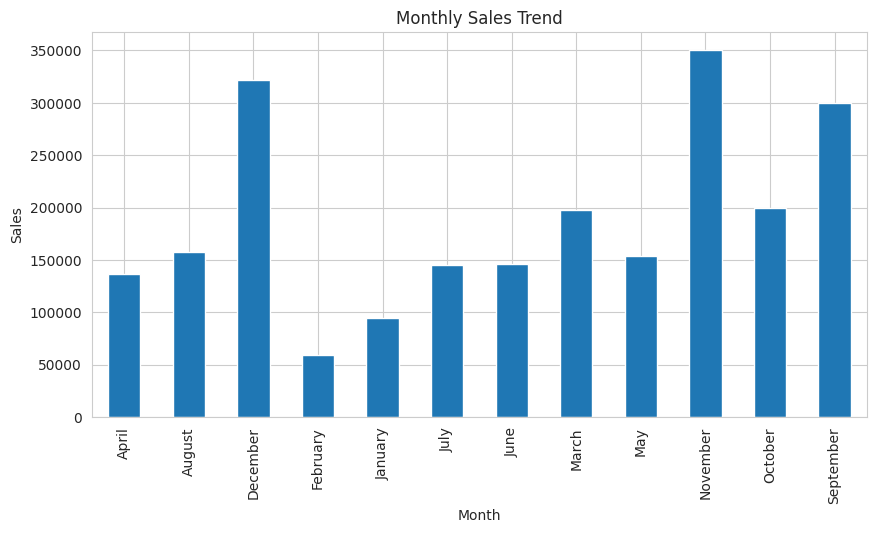

In [22]:
monthly_sales = df.groupby('Month_Name')['Sales'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(kind='bar')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

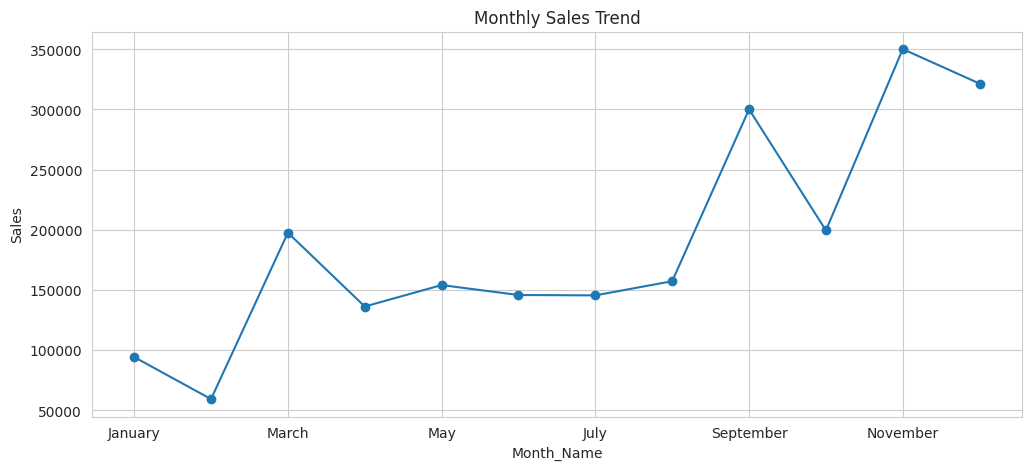

In [23]:
month_order = ['January','February','March','April',
               'May','June','July','August',
               'September','October','November','December']

monthly_sales = df.groupby('Month_Name')['Sales'].sum()

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.ylabel('Sales')

plt.show()

# Year-wise Sales Trend

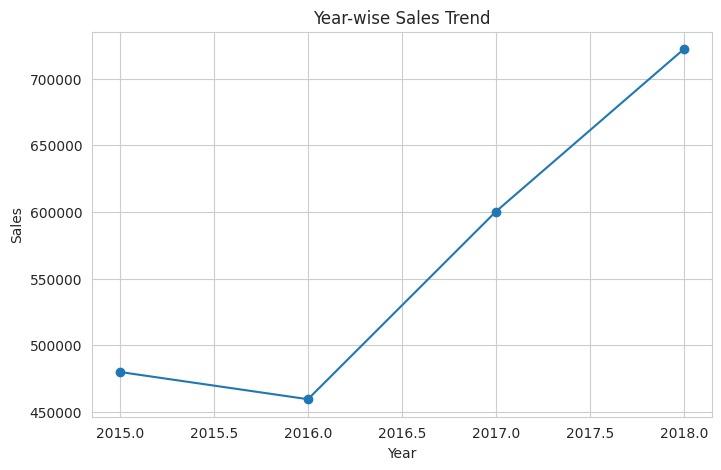

In [24]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8,5))

yearly_sales.plot(marker='o')

plt.title('Year-wise Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.show()

# Regional Sales Analysis

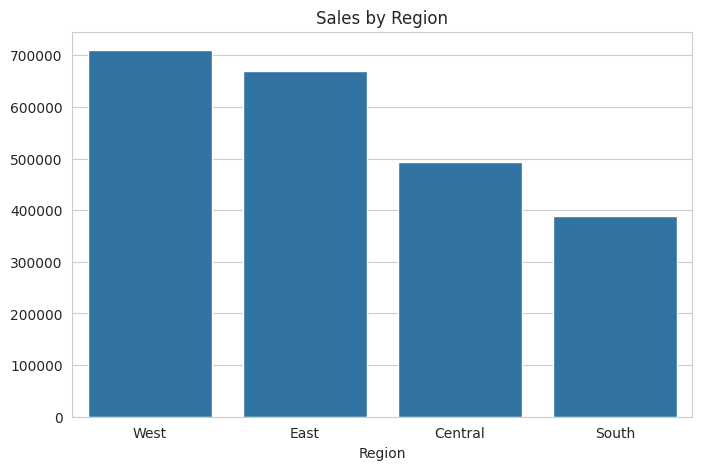

In [25]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title('Sales by Region')

plt.show()

# State-wise Sales

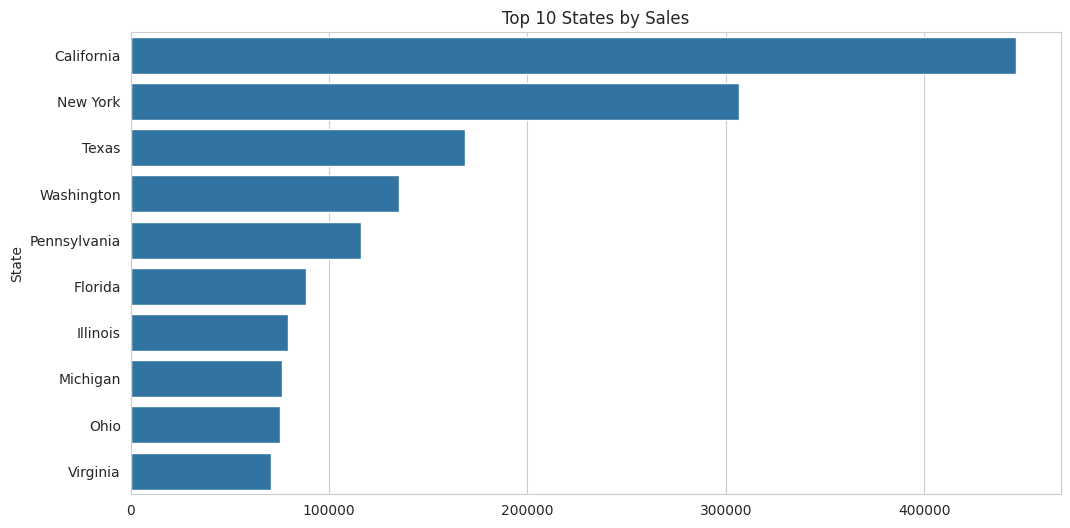

In [26]:
top_states = df.groupby('State')['Sales'].sum() \
               .sort_values(ascending=False) \
               .head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title('Top 10 States by Sales')

plt.show()

# Category Analysis

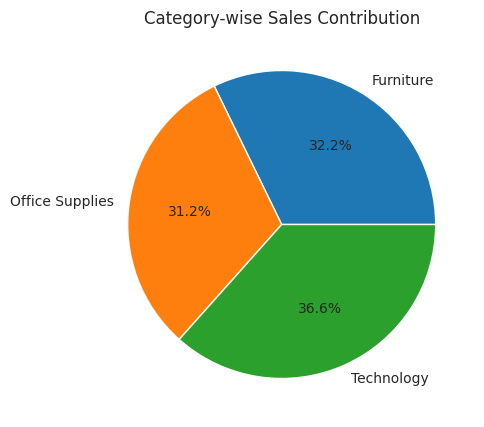

In [27]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%'
)

plt.title('Category-wise Sales Contribution')

plt.show()

# Sub Category Analysis

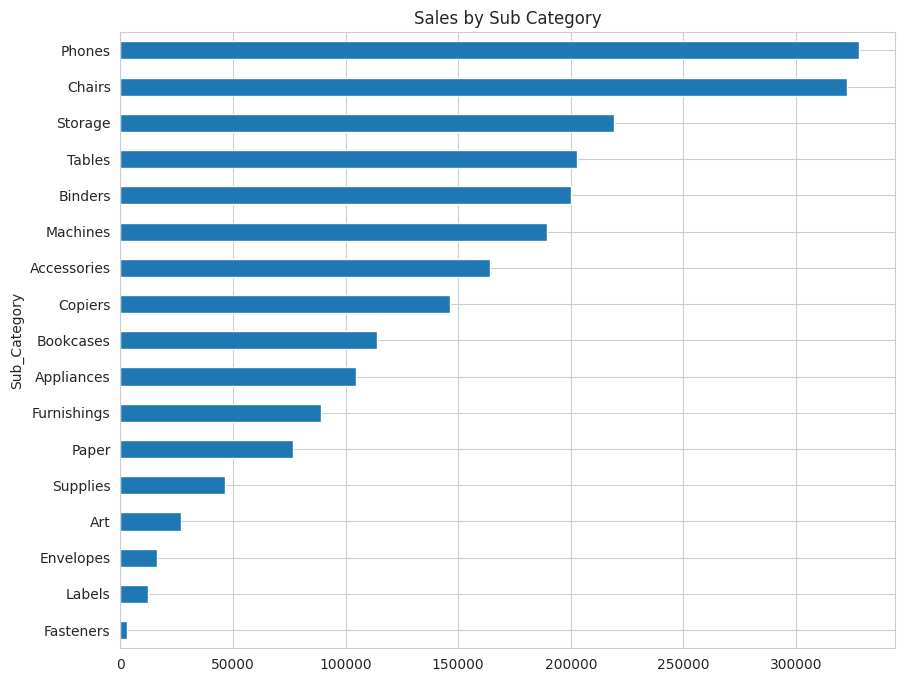

In [28]:
subcategory_sales = df.groupby('Sub_Category')['Sales'].sum() \
                      .sort_values()

plt.figure(figsize=(10,8))

subcategory_sales.plot(kind='barh')

plt.title('Sales by Sub Category')

plt.show()

# Top 10 Products

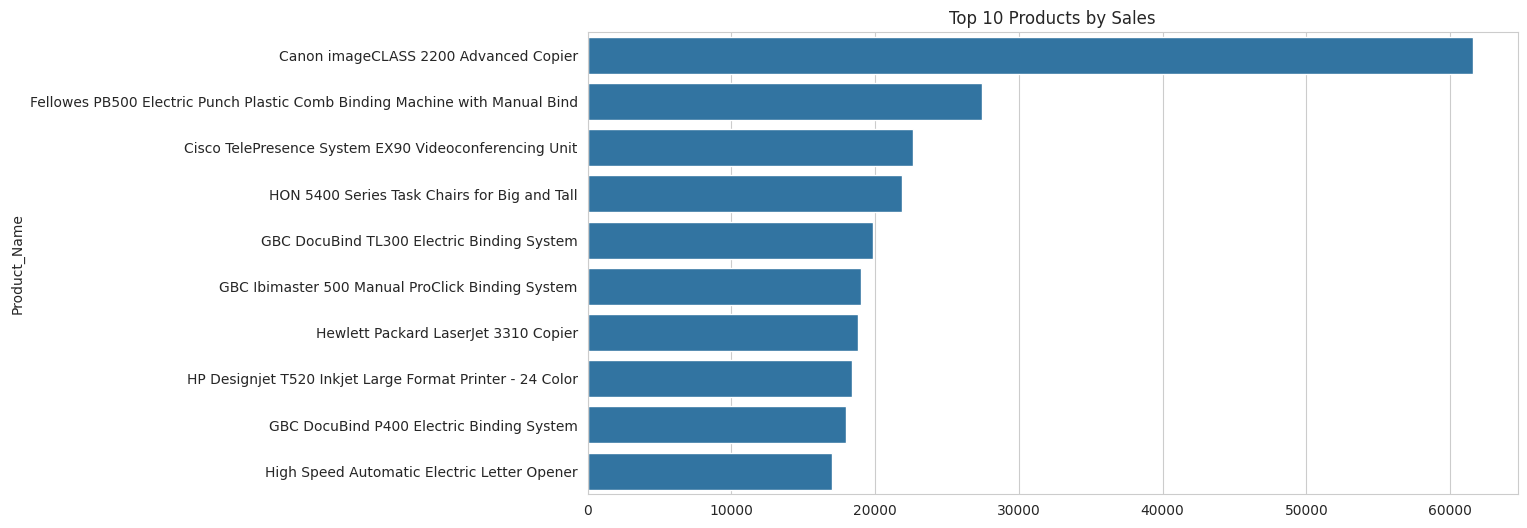

In [29]:
top_products = df.groupby('Product_Name')['Sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top 10 Products by Sales')

plt.show()

# Bottom 10 Products

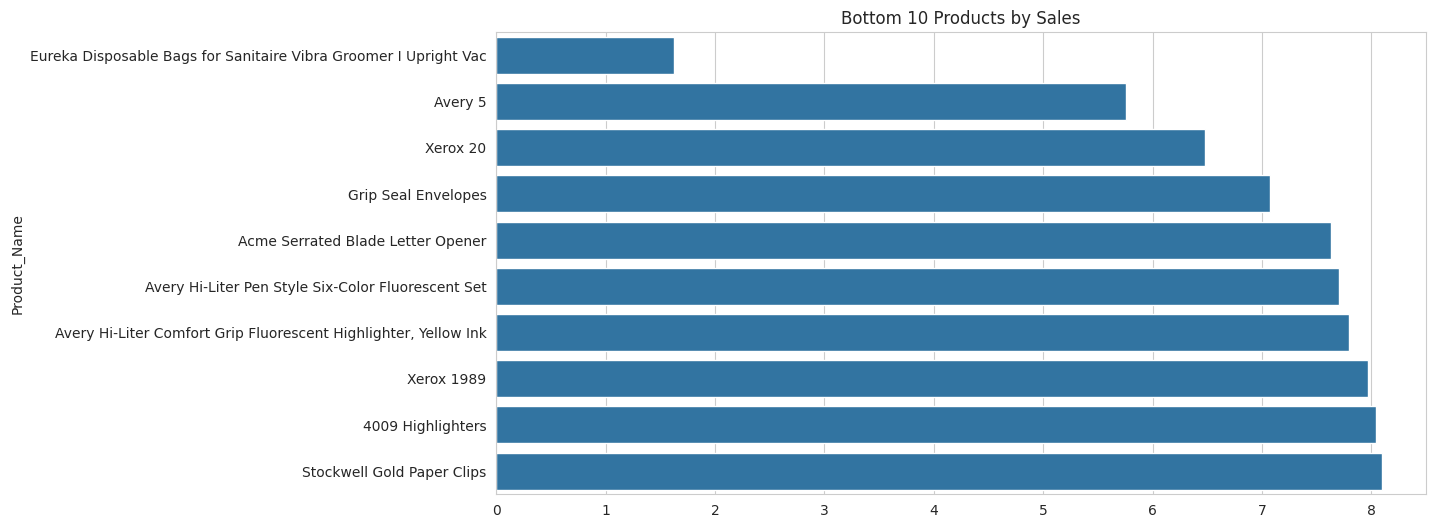

In [30]:
bottom_products = df.groupby('Product_Name')['Sales'].sum() \
                    .sort_values() \
                    .head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=bottom_products.values,
    y=bottom_products.index
)

plt.title('Bottom 10 Products by Sales')

plt.show()

# Customer Segment Analysis

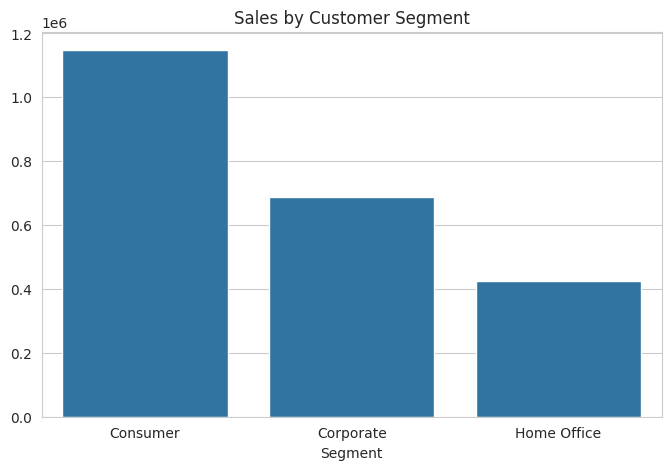

In [31]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title('Sales by Customer Segment')

plt.show()

# Ship Mode Analysis

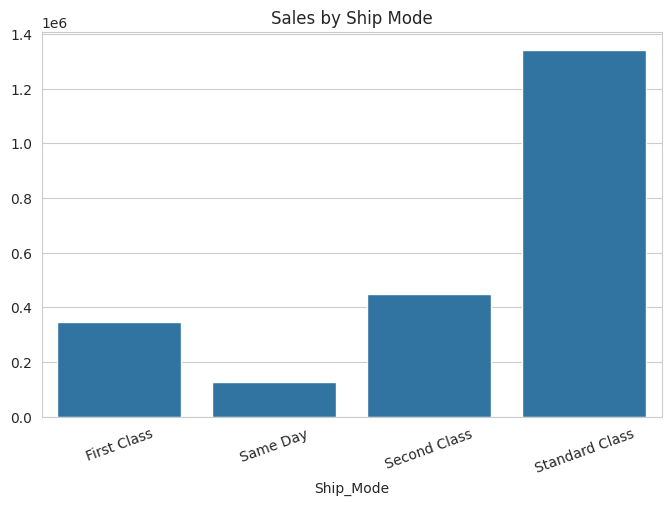

In [32]:
ship_sales = df.groupby('Ship_Mode')['Sales'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=ship_sales.index,
    y=ship_sales.values
)

plt.title('Sales by Ship Mode')

plt.xticks(rotation=20)

plt.show()

# Top 10 Customers

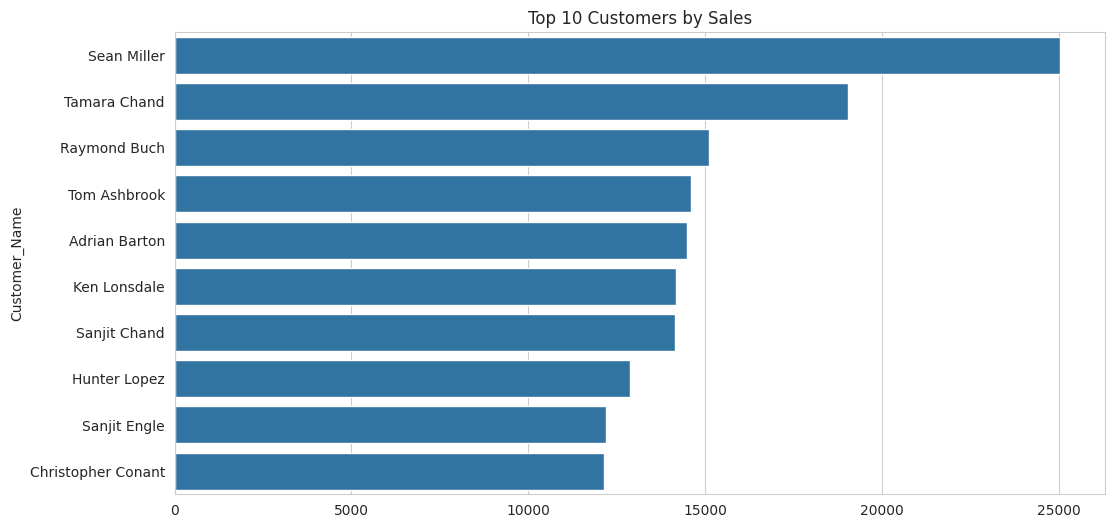

In [33]:
top_customers = df.groupby('Customer_Name')['Sales'].sum() \
                  .sort_values(ascending=False) \
                  .head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title('Top 10 Customers by Sales')

plt.show()

# Category and sub-category Sales

In [38]:
fig = px.sunburst(
    df,
    path=['Category', 'Sub_Category'],
    values='Sales',
    title='Category & Sub-Category Sales Distribution'
)

fig.show()

# Sub-category VS Region

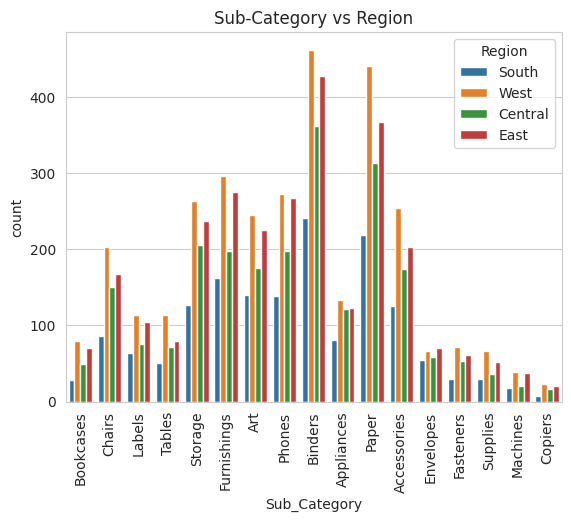

In [43]:
sns.countplot(x='Sub_Category', hue='Region', data=df)
plt.xticks(rotation=90)
plt.title("Sub-Category vs Region")
plt.show()

# Monthly and yearly sales

In [46]:
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()

fig = px.line(
    monthly_sales,
    x='Month',
    y='Sales',
    color='Year',
    title='Monthly Sales Trend'
)

fig.show()